# DALI Torchvision API

Starting from DALI 2.1 a Torchvision-compatible API is available under the `experimental` namespace.
It provides GPU-accelerated drop-in replacements for `torchvision.transforms.v2` operators,
letting you keep existing Torchvision-style code while transparently offloading work to DALI pipelines.

Two complementary APIs are provided:

| Style | Import | Usage |
|---|---|---|
| **Object-oriented** | `nvidia.dali.experimental.torchvision` | Stateful operator objects chained via `Compose` |
| **Functional** | `nvidia.dali.experimental.torchvision.v2.functional` | Stateless functions, one call per operation |

## Setup

Import both the object-oriented API (aliased `dtv`) and the functional API (aliased `dtv_fn`),
alongside the standard Torchvision counterparts for comparison.

In [1]:
import torch
import torchvision.transforms.v2 as tv
import torchvision.transforms.v2.functional as tv_fn
from PIL import Image
import numpy as np

# DALI Torchvision API — object-oriented
import nvidia.dali.experimental.torchvision as dtv

# DALI Torchvision API — functional
import nvidia.dali.experimental.torchvision.v2.functional as dtv_fn

print("DALI operators available:", dtv.__all__)
print("DALI functional ops available:", dtv_fn.__all__)

DALI operators available: ['CenterCrop', 'ColorJitter', 'Compose', 'GaussianBlur', 'Grayscale', 'Normalize', 'Pad', 'RandomHorizontalFlip', 'RandomVerticalFlip', 'Resize']
DALI functional ops available: ['center_crop', 'gaussian_blur', 'horizontal_flip', 'normalize', 'pad', 'resize', 'rgb_to_grayscale', 'to_grayscale', 'vertical_flip']


## Sample data

We create a small synthetic RGB `PIL.Image` and a matching `torch.Tensor` (CHW layout)
to illustrate both input modes.

In [2]:
# 64x64 RGB image with a simple colour gradient
H, W = 64, 64
arr = np.zeros((H, W, 3), dtype=np.uint8)
arr[:, :, 0] = np.linspace(0, 255, W, dtype=np.uint8)  # red gradient
arr[:, :, 1] = np.linspace(0, 255, H, dtype=np.uint8)[:, None]  # green gradient
arr[:, :, 2] = 128  # constant blue

pil_img = Image.fromarray(arr, mode="RGB")
print("PIL image:", pil_img.size, pil_img.mode)

# torch.Tensor in CHW format (as produced by torchvision.transforms.v2.ToImage)
tensor_img = (
    tv_fn.pil_to_tensor(pil_img).contiguous().float()
)  # shape: (3, 64, 64)
print("torch.Tensor shape:", tensor_img.shape)

PIL image: (64, 64) RGB
torch.Tensor shape: torch.Size([3, 64, 64])


## Visual Pipeline Example

Loading real images from disk and applying a DALI Torchvision pipeline to visualise the transformations side-by-side.

In [3]:
import os
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

IMAGE_DIR = "../data/images"


def collect_images(image_dir: str, n: int = 8):
    """Return up to *n* PIL images found recursively under *image_dir*."""
    paths = []
    for root, _, files in os.walk(image_dir):
        for fname in sorted(files):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(root, fname))
    return [Image.open(p).convert("RGB") for p in paths[:n]]


def show_pil_images(images, title: str = "", columns: int = 4):
    """Display a list of PIL images in a grid."""
    n = len(images)
    rows = (n + columns - 1) // columns
    fig = plt.figure(figsize=(16, (16 // columns) * rows))
    if title:
        fig.suptitle(title, fontsize=14, y=1.02)
    gs = gridspec.GridSpec(rows, columns)
    for j in range(rows * columns):
        ax = plt.subplot(gs[j])
        ax.axis("off")
        if j < n:
            ax.imshow(images[j])
    plt.tight_layout()
    plt.show()


original_images = collect_images(IMAGE_DIR, n=8)
print(f"Loaded {len(original_images)} images")
print("Sizes:", [img.size for img in original_images])

Loaded 8 images
Sizes: [(640, 480), (640, 480), (640, 597), (640, 425), (640, 427), (640, 427), (640, 427), (640, 446)]


### Original images

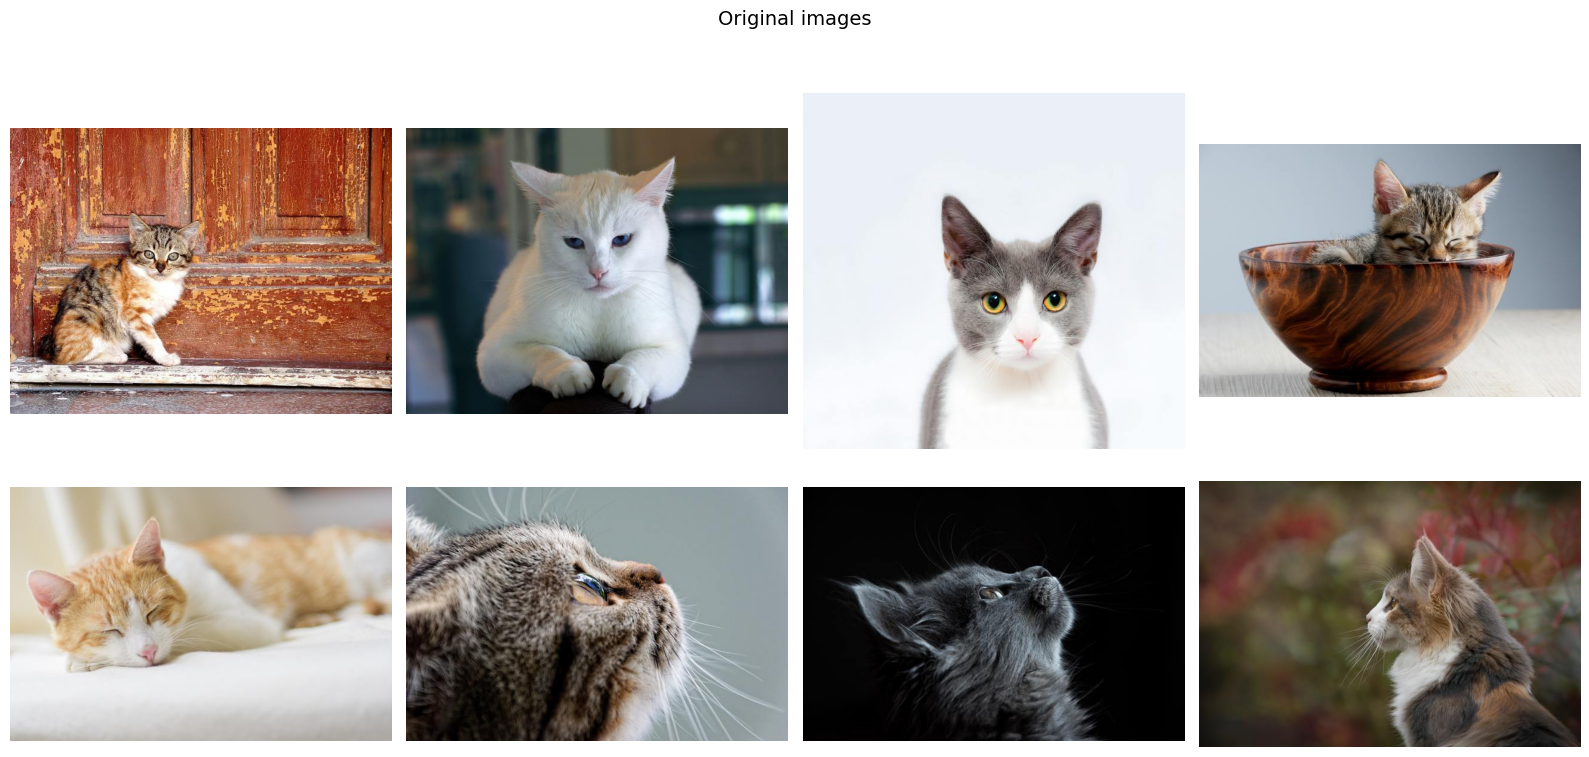

In [4]:
show_pil_images(original_images, title="Original images")

### Augmentation pipeline

Apply a sequence of operators that resize, randomly flip, convert to grayscale, and add padding — the same operators you would use with `torchvision.transforms.v2.Compose`.

In [5]:
augment = dtv.Compose(
    [
        dtv.Resize(size=(128, 128)),
        dtv.RandomHorizontalFlip(p=0.5),
        dtv.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
        dtv.Pad(padding=8, padding_mode="reflect"),
    ]
)

augmented_images = [augment(img) for img in original_images]
print(f"Augmented {len(augmented_images)} images")
print("Output sizes:", [img.size for img in augmented_images])

Augmented 8 images
Output sizes: [(144, 144), (144, 144), (144, 144), (144, 144), (144, 144), (144, 144), (144, 144), (144, 144)]


### Augmented images

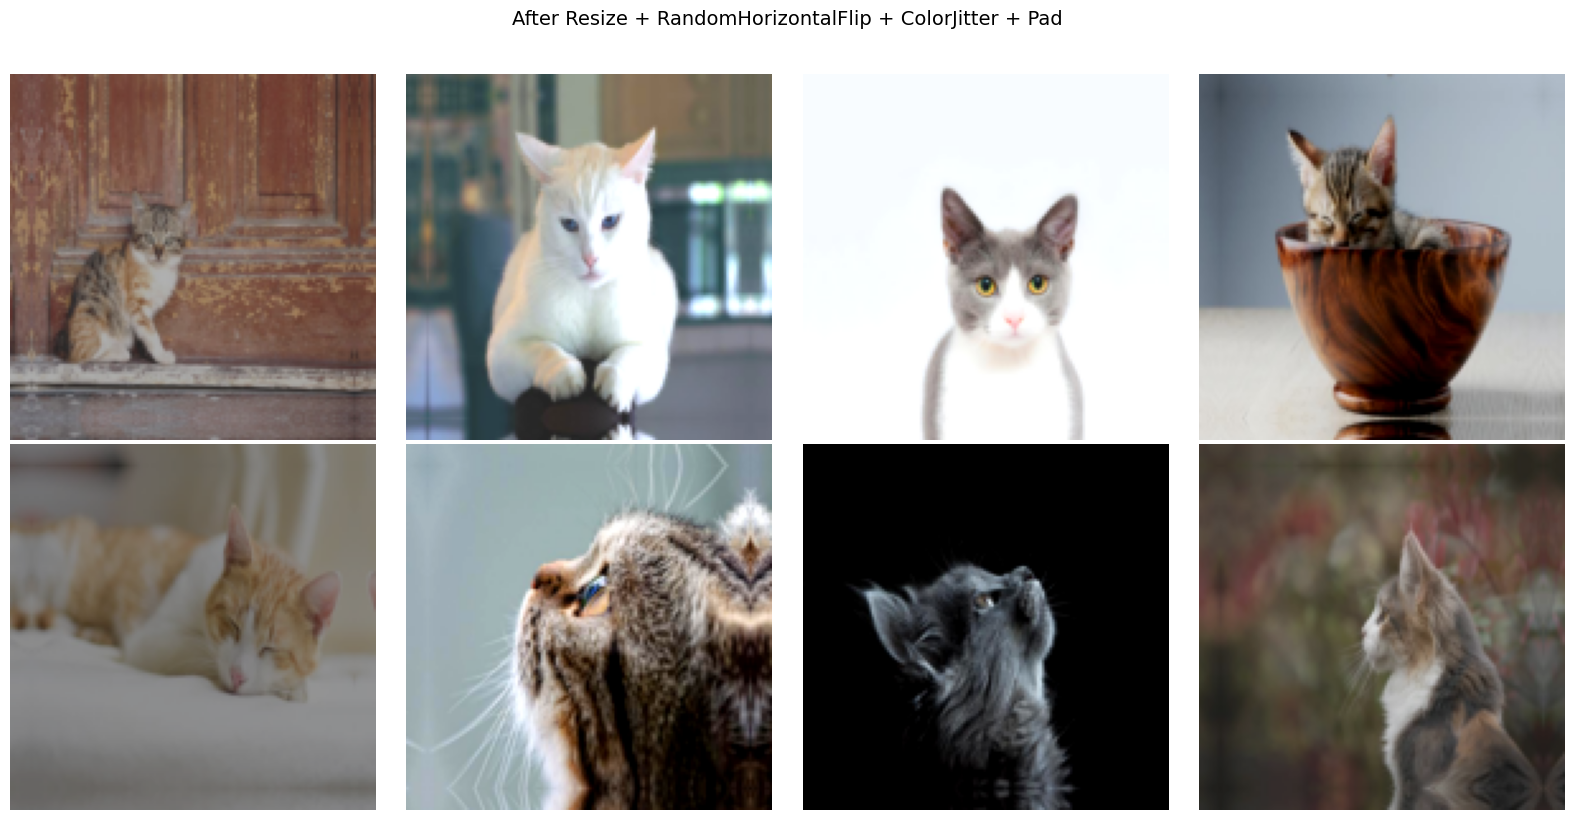

In [6]:
show_pil_images(
    augmented_images,
    title="After Resize + RandomHorizontalFlip + ColorJitter + Pad",
)

## Object-oriented API

The class-based API mirrors `torchvision.transforms.v2`: instantiate an operator and call it.
Due to DALI's pipeline design, **operators must be wrapped inside `dtv.Compose`** — the `Compose`
object builds and owns the underlying DALI pipeline.

```python
pipeline = dtv.Compose(
    [
        dtv.Resize(size=(128, 128)),
        dtv.RandomHorizontalFlip(p=0.5),
        ...
    ]
)
output = pipeline(img)
```

`Compose` detects the input type automatically:
- `PIL.Image` → uses an HWC pipeline, returns `PIL.Image`
- `torch.Tensor` (CHW) → uses a CHW pipeline, returns `torch.Tensor`

### PIL Image input

In [7]:
# Build a DALI pipeline that resizes and pads
pipeline_pil = dtv.Compose(
    [
        dtv.Resize(size=(32, 32)),
        dtv.Pad(padding=4, padding_mode="reflect"),
    ]
)

out_dali = pipeline_pil(pil_img)
print("DALI output type:", type(out_dali), "size:", out_dali.size)

# Equivalent Torchvision pipeline for comparison
pipeline_tv = tv.Compose(
    [
        tv.Resize(size=(32, 32)),
        tv.Pad(padding=4, padding_mode="reflect"),
    ]
)

out_tv = pipeline_tv(pil_img)
print("TV   output type:", type(out_tv), "size:", out_tv.size)

# Verify pixel-level equality — cast to float since torch.allclose requires floating-point tensors
dali_t = tv_fn.pil_to_tensor(out_dali).float()
tv_t = tv_fn.pil_to_tensor(out_tv).float()
print("Outputs are equal:", torch.allclose(dali_t, tv_t, rtol=0, atol=1))

DALI output type: <class 'PIL.Image.Image'> size: (40, 40)
TV   output type: <class 'PIL.Image.Image'> size: (40, 40)
Outputs are equal: True


### torch.Tensor input

Pass a CHW `torch.Tensor` directly — `Compose` will use the CHW pipeline automatically
and return a `torch.Tensor` of the same shape convention.

In [8]:
pipeline_tensor = dtv.Compose(
    [
        dtv.CenterCrop(size=(48, 48)),
        dtv.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Normalize expects float input in [0, 1] range; scale from [0, 255]
tensor_img_01 = tensor_img / 255.0
out_dali_t = pipeline_tensor(tensor_img_01)
print("DALI output shape:", out_dali_t.shape, "dtype:", out_dali_t.dtype)

pipeline_tv_t = tv.Compose(
    [
        tv.CenterCrop(size=(48, 48)),
        tv.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

out_tv_t = pipeline_tv_t(tensor_img_01)
print("TV   output shape:", out_tv_t.shape, "dtype:", out_tv_t.dtype)
print("Max absolute diff:", (out_dali_t - out_tv_t).abs().max().item())

DALI output shape: torch.Size([3, 48, 48]) dtype: torch.float32
TV   output shape: torch.Size([3, 48, 48]) dtype: torch.float32
Max absolute diff: 1.1920928955078125e-07


## Functional API

The functional API (`dtv_fn`) exposes stateless functions — the same operations without
needing operator objects or a `Compose` wrapper.
The call signature intentionally mirrors `torchvision.transforms.v2.functional`.

```python
import nvidia.dali.experimental.torchvision.v2.functional as dtv_fn

output = dtv_fn.resize(img, size=(224, 224))
```

Both `PIL.Image` and `torch.Tensor` (CHW) inputs are supported for most functions.

In [9]:
# Functional API on a PIL Image
resized_pil = dtv_fn.resize(pil_img, size=[32, 32])
flipped_pil = dtv_fn.horizontal_flip(pil_img)
gray_pil = dtv_fn.to_grayscale(pil_img)
padded_pil = dtv_fn.pad(pil_img, padding=8, padding_mode="edge")
cropped_pil = dtv_fn.center_crop(pil_img, output_size=(48, 48))

print("resize       :", resized_pil.size)
print("hflip        :", flipped_pil.size)
print("grayscale    :", gray_pil.size, gray_pil.mode)
print("pad (edge, 8):", padded_pil.size)
print("center_crop  :", cropped_pil.size)

resize       : (32, 32)
hflip        : (64, 64)
grayscale    : (64, 64) L
pad (edge, 8): (80, 80)
center_crop  : (48, 48)


In [10]:
# Functional API on a torch.Tensor (CHW, float32)
# Scale tensor_img to [0, 1] dynamic range before processing
scaled_tensor_img = tensor_img / tensor_img.max()

resized_t = dtv_fn.resize(scaled_tensor_img, size=[32, 32])
flipped_t = dtv_fn.horizontal_flip(scaled_tensor_img)
norm_t = dtv_fn.normalize(
    scaled_tensor_img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
)
blurred_t = dtv_fn.gaussian_blur(scaled_tensor_img, kernel_size=5, sigma=1.0)

print("resize       :", resized_t.shape)
print("hflip        :", flipped_t.shape)
print("normalize    :", norm_t.shape, "mean:", norm_t.mean().item())
print("gaussian_blur:", blurred_t.shape)

resize       : torch.Size([3, 32, 32])
hflip        : torch.Size([3, 64, 64])
normalize    : torch.Size([3, 64, 64]) mean: 0.22406327724456787
gaussian_blur: torch.Size([3, 64, 64])


## DALI Extensions

The DALI implementation extends the original Torchvision API with two additional parameters
that provide fine-grained control over pipeline execution:

| Parameter | Scope | Default | Description |
|---|---|---|---|
| `device` | Each operator | `"cpu"` | Target execution device: `"cpu"` or `"gpu"` |
| `batch_size` | `Compose` only | `16` | Maximum number of samples processed per pipeline call |

> **Note:** Mixing `device` types across operators inside a single `Compose` is not currently supported.
All operators must target the same device.

> **Note:** When `batch_size > 1`, the input to `Compose` must be a `torch.Tensor`
with a leading batch dimension `(N, C, H, W)`.

### GPU pipeline

Pass `device="gpu"` to each operator to run the pipeline on the GPU.
The output tensor resides on the GPU; call `.cpu()` to move it back if needed.
It is important to align input data location and operator execution device — if they differ,
an automatic copy is performed with a warning.

In [11]:
if torch.cuda.is_available():
    pipeline_gpu = dtv.Compose(
        [
            dtv.Resize(size=(32, 32), device="gpu"),
            dtv.Pad(padding=4, padding_mode="reflect", device="gpu"),
        ]
    )

    # Input tensor on GPU
    tensor_gpu = tensor_img.cuda()
    out_gpu = pipeline_gpu(tensor_gpu)

    print("Output device:", out_gpu.device)
    print("Output shape :", out_gpu.shape)

    # Compare to CPU reference
    pipeline_cpu = dtv.Compose(
        [
            dtv.Resize(size=(32, 32), device="cpu"),
            dtv.Pad(padding=4, padding_mode="reflect", device="cpu"),
        ]
    )
    out_cpu = pipeline_cpu(tensor_img)
    print(
        "Max absolute diff (cpu vs gpu):",
        (out_cpu - out_gpu.cpu()).abs().max().item(),
    )
else:
    print("CUDA not available — skipping GPU example.")

Output device: cuda:0
Output shape : torch.Size([3, 40, 40])


Max absolute diff (cpu vs gpu): 0.0


### GPU functional API

The functional API also accepts a `device` parameter.

In [12]:
if torch.cuda.is_available():
    tensor_gpu = tensor_img.cuda()

    resized_gpu = dtv_fn.resize(tensor_gpu, size=[32, 32], device="gpu")
    flipped_gpu = dtv_fn.horizontal_flip(tensor_gpu, device="gpu")

    print("resize  (gpu):", resized_gpu.shape, resized_gpu.device)
    print("hflip   (gpu):", flipped_gpu.shape, flipped_gpu.device)
else:
    print("CUDA not available — skipping GPU functional example.")

resize  (gpu): torch.Size([3, 32, 32]) cuda:0
hflip   (gpu): torch.Size([3, 64, 64]) cuda:0


### Batch processing

Set `batch_size` on `Compose` to process multiple samples in a single pipeline run.
The input must be a 4-D `torch.Tensor` of shape `(N, C, H, W)` where `N ≤ batch_size`.

In [13]:
BATCH = 4

# Create a batch of N=4 images (NCHW)
batch = tensor_img.unsqueeze(0).repeat(BATCH, 1, 1, 1)  # (4, 3, 64, 64)
print("Input batch shape:", batch.shape)

pipeline_batch = dtv.Compose(
    [
        dtv.Resize(size=(32, 32)),
        dtv.RandomHorizontalFlip(p=0.5),
    ],
    batch_size=BATCH,
)

out_batch = pipeline_batch(batch)
print("Output batch shape:", out_batch.shape)  # (4, 3, 32, 32)

Input batch shape: torch.Size([4, 3, 64, 64])
Output batch shape: torch.Size([4, 3, 32, 32])


## Complete pipeline example

A pre-processing pipeline using the DALI API, following the standard ResNet pre-processing steps — 
structurally identical to the Torchvision version but executed by DALI.

In [14]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# --- DALI pipeline ---
dali_preprocess = dtv.Compose(
    [
        dtv.Resize(size=256),
        dtv.CenterCrop(size=(224, 224)),
        dtv.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

# --- Equivalent Torchvision pipeline ---
tv_preprocess = tv.Compose(
    [
        tv.Resize(size=256),
        tv.CenterCrop(size=(224, 224)),
        tv.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

# Use a larger synthetic image to make the resize step meaningful.
# Scale to [0, 1] — ImageNet mean/std constants assume this range.
large_arr = np.random.randint(0, 256, (3, 480, 640), dtype=np.uint8)
large_tensor = (
    torch.from_numpy(large_arr).float() / 255.0
)  # (3, 480, 640), values in [0, 1]

out_dali = dali_preprocess(large_tensor)
out_tv = tv_preprocess(large_tensor)

print("DALI output shape:", out_dali.shape)
print("TV   output shape:", out_tv.shape)
print("Max absolute diff:", (out_dali - out_tv).abs().max().item())

DALI output shape: torch.Size([3, 224, 224])
TV   output shape: torch.Size([3, 224, 224])
Max absolute diff: 4.184246063232422e-05
